In [2]:
import numpy as np
import pandas as pd
import os

# Prepare Data

In [3]:
dir_path = "./data/processed/purpleair/"

# Seprate data by season
X_spring = []
Y_spring = []
X_summer = []
Y_summer = []
X_fall = []
Y_fall = []
X_winter = []
Y_winter = []

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    # spring
    df_temp = df[df["month"].isin([3, 4, 5])]
    X_spring.append(df_temp[["longitude", "latitude"]].values)
    Y_spring.append(df_temp["pm25"].values)
    # summer
    df_temp = df[df["month"].isin([6, 7, 8])]
    X_summer.append(df_temp[["longitude", "latitude"]].values)
    Y_summer.append(df_temp["pm25"].values)
    # fall
    df_temp = df[df["month"].isin([9, 10, 11])]
    X_fall.append(df_temp[["longitude", "latitude"]].values)
    Y_fall.append(df_temp["pm25"].values)
    # winter
    df_temp = df[df["month"].isin([12, 1, 2])]
    X_winter.append(df_temp[["longitude", "latitude"]].values)
    Y_winter.append(df_temp["pm25"].values)

X_spring = np.array(X_spring).transpose(1, 0, 2)
Y_spring = np.array(Y_spring).transpose(1, 0)
X_summer = np.array(X_summer).transpose(1, 0, 2)
Y_summer = np.array(Y_summer).transpose(1, 0)
X_fall = np.array(X_fall).transpose(1, 0, 2)
Y_fall = np.array(Y_fall).transpose(1, 0)
X_winter = np.array(X_winter).transpose(1, 0, 2)
Y_winter = np.array(Y_winter).transpose(1, 0)

# X: (time steps, num of sensors, 2)
# Y: (time steps, num of sensors)
print(X_spring.shape)
print(Y_spring.shape)
print(X_summer.shape)
print(Y_summer.shape)
print(X_fall.shape)
print(Y_fall.shape)
print(X_winter.shape)
print(Y_winter.shape)

(2208, 32, 2)
(2208, 32)
(2208, 32, 2)
(2208, 32)
(2184, 32, 2)
(2184, 32)
(2160, 32, 2)
(2160, 32)


In [4]:
# train test split
def train_test_split(X, Y, train_ratio=0.8, seed=42):
    """
    param X: (time steps, num of sensors, 2)
    param Y: (time steps, num of sensors)
    param train_ratio: ratio of training data
    param seed: random seed
    """
    # set random seed
    np.random.seed(seed)

    # get train and test index
    n_steps, n_sensors, n_features = X.shape
    n_train = int(n_sensors * train_ratio)
    permutation = np.random.permutation(n_sensors)
    train_idx = permutation[:n_train]
    test_idx = permutation[n_train:]

    # split train and test
    X_train = X[:, train_idx, :]
    Y_train = Y[:, train_idx]
    X_test = X[:, test_idx, :]
    Y_test = Y[:, test_idx]

    return X_train, Y_train, X_test, Y_test

# Inverse Distance Weighting

In [6]:
class IDW:
    def __init__(self, X_train, Y_train):
        """
        Inverse Distance Weighting

        param X_train: numpy array of shape (n_train, 2); 2 stands for 2-D location
        param Y_train: numpy array of shape (n_train, )
        """
        self.X_train = X_train
        self.Y_train = Y_train

    def predict(self, X_test):
        """
        param X_test: numpy array of shape (n_test, 2)
        """
        # get distance matrix of shape (n_test, n_train)
        diff = X_test[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
        distm = np.sum(diff ** 2, axis=-1)

        # get inverse distance matrix of shape (n_test, n_train)
        inv_distm = 1 / distm

        # get prediction of shape (n_test, )
        pred = np.sum(inv_distm * self.Y_train[np.newaxis, :], axis=-1) / np.sum(inv_distm, axis=-1)

        return pred

In [28]:
# Test for 10 different random seeds
MAE_spring = []
MAE_summer = []
MAE_fall = []
MAE_winter = []
MSE_spring = []
MSE_summer = []
MSE_fall = []
MSE_winter = []
RMSE_spring = []
RMSE_summer = []
RMSE_fall = []
RMSE_winter = []

for seed in range(10):
    # spring
    # train test split
    X_train, Y_train, X_test, Y_test = train_test_split(X_spring, Y_spring, seed=seed)
    # IDW
    for t in range(len(X_train)):
        idw = IDW(X_train[t], Y_train[t])
        pred = idw.predict(X_test[t])
        MAE_spring.append(np.mean(np.abs(pred - Y_test[t])))
        MSE_spring.append(np.mean((pred - Y_test[t]) ** 2))
        RMSE_spring.append(np.sqrt(np.mean((pred - Y_test[t]) ** 2)))

    # summer
    # train test split
    X_train, Y_train, X_test, Y_test = train_test_split(X_summer, Y_summer, seed=seed)
    # IDW
    for t in range(len(X_train)):
        idw = IDW(X_train[t], Y_train[t])
        pred = idw.predict(X_test[t])
        MAE_summer.append(np.mean(np.abs(pred - Y_test[t])))
        MSE_summer.append(np.mean((pred - Y_test[t]) ** 2))
        RMSE_summer.append(np.sqrt(np.mean((pred - Y_test[t]) ** 2)))

    # fall
    # train test split
    X_train, Y_train, X_test, Y_test = train_test_split(X_fall, Y_fall, seed=seed)
    # IDW
    for t in range(len(X_train)):
        idw = IDW(X_train[t], Y_train[t])
        pred = idw.predict(X_test[t])
        MAE_fall.append(np.mean(np.abs(pred - Y_test[t])))
        MSE_fall.append(np.mean((pred - Y_test[t]) ** 2))
        RMSE_fall.append(np.sqrt(np.mean((pred - Y_test[t]) ** 2)))
    
    # winter
    # train test split
    X_train, Y_train, X_test, Y_test = train_test_split(X_winter, Y_winter, seed=seed)
    # IDW
    for t in range(len(X_train)):
        idw = IDW(X_train[t], Y_train[t])
        pred = idw.predict(X_test[t])
        MAE_winter.append(np.mean(np.abs(pred - Y_test[t])))
        MSE_winter.append(np.mean((pred - Y_test[t]) ** 2))
        RMSE_winter.append(np.sqrt(np.mean((pred - Y_test[t]) ** 2)))

print("MAE_spring: ", np.mean(MAE_spring))
print("MAE_summer: ", np.mean(MAE_summer))
print("MAE_fall: ", np.mean(MAE_fall))
print("MAE_winter: ", np.mean(MAE_winter))
print("MSE_spring: ", np.mean(MSE_spring))
print("MSE_summer: ", np.mean(MSE_summer))
print("MSE_fall: ", np.mean(MSE_fall))
print("MSE_winter: ", np.mean(MSE_winter))
print("RMSE_spring: ", np.mean(RMSE_spring))
print("RMSE_summer: ", np.mean(RMSE_summer))
print("RMSE_fall: ", np.mean(RMSE_fall))
print("RMSE_winter: ", np.mean(RMSE_winter))

MAE_spring:  2.089689685002148
MAE_summer:  1.89357169658773
MAE_fall:  3.313360066082439
MAE_winter:  2.9634744089202627
MSE_spring:  13.476159833278015
MSE_summer:  12.008607340599363
MSE_fall:  34.88781432494711
MSE_winter:  25.87447652362727
RMSE_spring:  2.988344478013846
RMSE_summer:  2.7586208205672036
RMSE_fall:  4.495560586970752
RMSE_winter:  3.9887802616081265


In [26]:
MSE_spring

[]

In [13]:
import scipy.stats as stats
print(stats.ttest_ind(MAE_spring, MAE_summer, equal_var=False))
print(stats.ttest_ind(MAE_spring, MAE_fall, equal_var=False))
print(stats.ttest_ind(MAE_spring, MAE_winter, equal_var=False))
print(stats.ttest_ind(MAE_summer, MAE_fall, equal_var=False))
print(stats.ttest_ind(MAE_summer, MAE_winter, equal_var=False))
print(stats.ttest_ind(MAE_fall, MAE_winter, equal_var=False))

Ttest_indResult(statistic=15.223958593780912, pvalue=3.3291259951934656e-52)
Ttest_indResult(statistic=-60.95534365919135, pvalue=0.0)
Ttest_indResult(statistic=-51.17709521099105, pvalue=0.0)
Ttest_indResult(statistic=-70.77884769855214, pvalue=0.0)
Ttest_indResult(statistic=-62.73000499849496, pvalue=0.0)
Ttest_indResult(statistic=15.227605234697497, pvalue=3.20718883955705e-52)


# Analysis by month

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data

In [9]:
dir_path = "./data/processed/purpleair/"

df_all = pd.DataFrame()

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    df_all = pd.concat([df_all, df])

def month_n2s(n):
    if n == 1:
        return "Jan"
    elif n == 2:
        return "Feb"
    elif n == 3:
        return "Mar"
    elif n == 4:
        return "Apr"
    elif n == 5:
        return "May"
    elif n == 6:
        return "Jun"
    elif n == 7:
        return "Jul"
    elif n == 8:
        return "Aug"
    elif n == 9:
        return "Sep"
    elif n == 10:
        return "Oct"
    elif n == 11:
        return "Nov"
    elif n == 12:
        return "Dec"

df_all["month_str"] = df_all["month"].apply(month_n2s)
df_all

,year,month,day,hour,minute,pm25,longitude,latitude,month_str
0,2022,3,1,0,0,3.673667,-119.72782,36.858067,Mar
1,2022,3,1,1,0,2.916667,-119.72782,36.858067,Mar
2,2022,3,1,2,0,2.909333,-119.72782,36.858067,Mar
3,2022,3,1,3,0,3.202167,-119.72782,36.858067,Mar
4,2022,3,1,4,0,3.850000,-119.72782,36.858067,Mar
...,...,...,...,...,...,...,...,...,...
8755,2023,2,28,19,0,1.694667,-119.77299,36.785336,Feb
8756,2023,2,28,20,0,5.311500,-119.77299,36.785336,Feb
8757,2023,2,28,21,0,3.255667,-119.77299,36.785336,Feb
8758,2023,2,28,22,0,1.492500,-119.77299,36.785336,Feb


/var/folders/h9/6347jhns5fv4jgpmcl4fl7dh0000gn/T/ipykernel_3782/1164968863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="month_str", y="pm25", data=df_all.sort_values(by="month"),


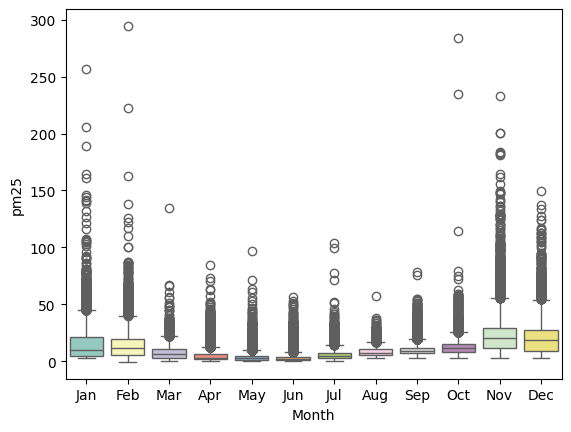

In [10]:
sns.boxplot(x="month_str", y="pm25", data=df_all.sort_values(by="month"),
            palette="Set3")
plt.xlabel("Month")
plt.show()

/var/folders/h9/6347jhns5fv4jgpmcl4fl7dh0000gn/T/ipykernel_3782/1991349509.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="month_str", y="pm25", data=df_all.sort_values(by="month"),


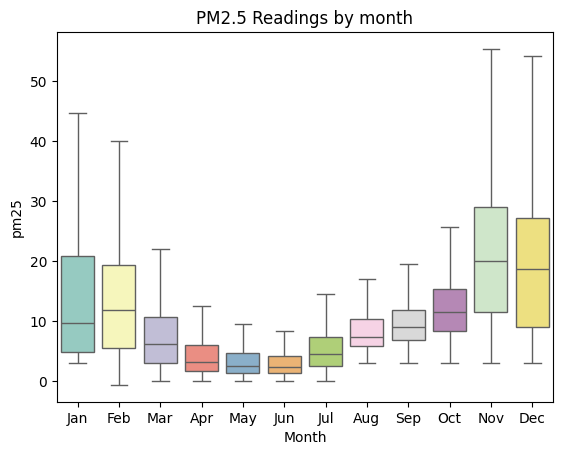

In [19]:
sns.boxplot(x="month_str", y="pm25", data=df_all.sort_values(by="month"),
            showfliers=False, palette="Set3")
plt.xlabel("Month")
plt.title("PM2.5 Readings by month")
plt.show()

In [23]:
def count_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    
    return len(outliers)

for month in range(1, 13):
    n_samples = len(df_all[df_all["month"] == month])
    n_outliers = count_outliers(df_all[df_all["month"] == month]["pm25"].values)
    print(f"Month {month} outlier proportion: {n_outliers} / {n_samples} = {n_outliers / n_samples}")

Month 1 outlier proportion: 588 / 23808 = 0.02469758064516129
Month 2 outlier proportion: 535 / 21504 = 0.02487909226190476
Month 3 outlier proportion: 384 / 23808 = 0.016129032258064516
Month 4 outlier proportion: 1663 / 23040 = 0.07217881944444444
Month 5 outlier proportion: 1942 / 23808 = 0.08156922043010753
Month 6 outlier proportion: 2360 / 23040 = 0.10243055555555555
Month 7 outlier proportion: 1121 / 23808 = 0.04708501344086022
Month 8 outlier proportion: 449 / 23808 = 0.018859206989247312
Month 9 outlier proportion: 935 / 23040 = 0.040581597222222224
Month 10 outlier proportion: 970 / 23808 = 0.04074260752688172
Month 11 outlier proportion: 602 / 23040 = 0.026128472222222223
Month 12 outlier proportion: 364 / 23808 = 0.015288978494623656


# HeatMap Video

In [24]:
X_all = np.concatenate([X_spring, X_summer, X_fall, X_winter], axis=0)
Y_all = np.concatenate([Y_spring, Y_summer, Y_fall, Y_winter], axis=0)
print(X_all.shape)
print(Y_all.shape)

(8760, 32, 2)
(8760, 32)


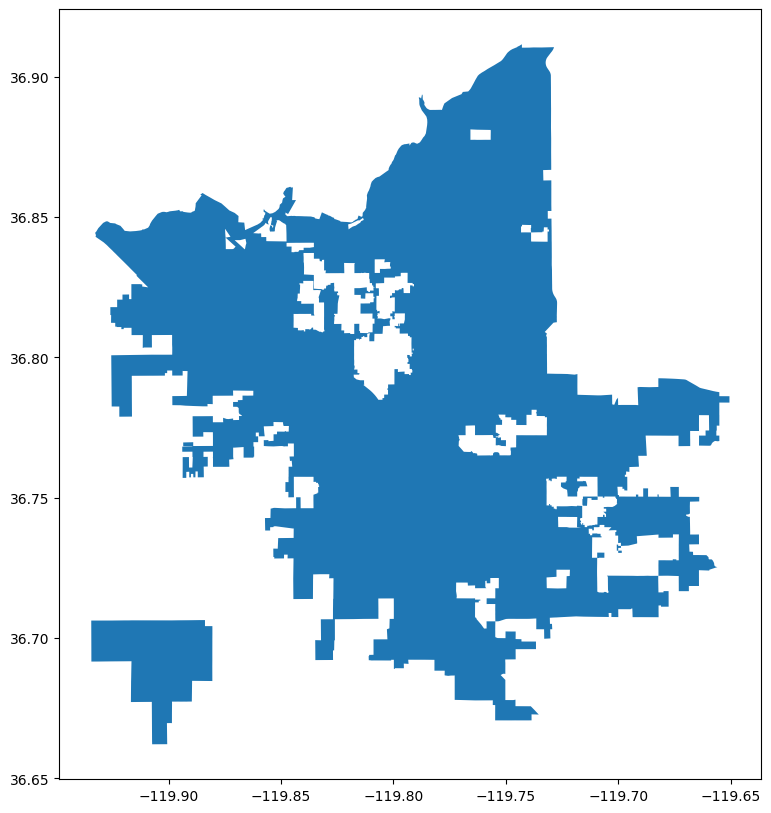

In [33]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib as mpl
import cv2
import geopandas as gpd
from fiona.crs import from_string
from tqdm import tqdm

def month_n2s(n):
    if n == 1:
        return "Jan"
    elif n == 2:
        return "Feb"
    elif n == 3:
        return "Mar"
    elif n == 4:
        return "Apr"
    elif n == 5:
        return "May"
    elif n == 6:
        return "Jun"
    elif n == 7:
        return "Jul"
    elif n == 8:
        return "Aug"
    elif n == 9:
        return "Sep"
    elif n == 10:
        return "Oct"
    elif n == 11:
        return "Nov"
    elif n == 12:
        return "Dec"
    
def fig_to_rgb(fig):
    canvas = FigureCanvas(fig)
    canvas.draw()
    buf = canvas.buffer_rgba()
    return np.array(buf)[:, :, :3]

# map
# Load Fresno Map
ca_map = gpd.read_file("../Map_Data/ca-places-boundaries/CA_Places_TIGER2016.shp")
crs = from_string("+proj=longlat +datum=WGS84 +no_defs")
ca_map = ca_map.to_crs(crs)
fresno_map = ca_map[ca_map["NAME"].isin(["Fresno"])]

# custom color map
color_list = [(0, "green"), (12 / 250, "yellow"), (35 / 250, "orange"), (55 / 250, "red"), (150 / 250, "purple"), (1, "maroon")]
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list("custom_cmap", color_list)

# visualize
fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax_fresno)

# map bound
map_bound = (-119.95, 36.65, -119.65, 36.95)

# create meshgrid
x = np.linspace(map_bound[0], map_bound[2], 50 * 2 + 1)[1::2]
y = np.linspace(map_bound[1], map_bound[3], 50 * 2 + 1)[1::2]
xx, yy = np.meshgrid(x, y)

In [34]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("map_change_purple_year.avi", fourcc, 10.0, (1000, 1000))

# all purple air sensors' location
coords_purple = X_all[0].transpose(1, 0)

for t in tqdm(range(len(X_all))):
    # get estimator
    estimator_purple = IDW(X_all[t], Y_all[t])

    # get prediction for each grid
    pred = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred.append(estimator_purple.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred = np.array(pred).reshape(xx.shape)

    # visualize
    fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
    sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_fresno.scatter(coords_purple[0], coords_purple[1],
                    c=Y_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    
    # set title
    hour = str(df.loc[t, "hour"])
    hour = hour if len(hour) == 2 else "0" + hour
    day = df.loc[t, "day"]
    month = month_n2s(df.loc[t, "month"])
    year = df.loc[t, "year"]
    ax_fresno.set_title(f"{hour}:00 {month} {day} {year}", fontsize=20)
    
    # create colorbar
    cbar = plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250],
                        label="PM2.5 (ug / m^3)")
    cbar.ax.set_ylabel("PM2.5 (ug / m^3)", rotation=270, labelpad=20,
                        fontsize=20)

    # write image to video
    image = fig_to_rgb(fig_fresno)[:, :, ::-1]
    plt.close(fig_fresno)
    out.write(image)
    # print(f"Frame {t + 1}")
    # if t == 10:
    #     print("finished")
    #     break

print("Finised")
out.release()

100%|██████████| 8760/8760 [14:15<00:00, 10.24it/s]  

Finised


# Seasonal Decompose

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
data = np.mean(Y_all, axis=1)
data.shape

(8760,)

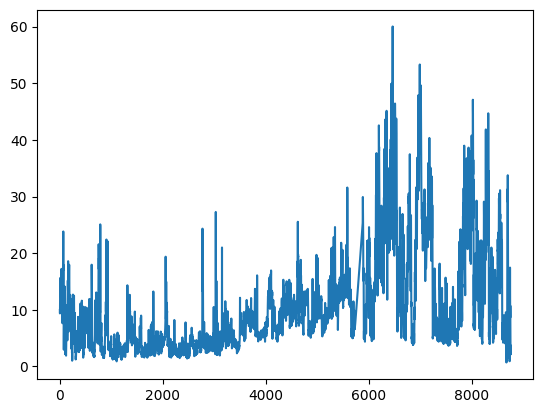

In [33]:
plt.plot(data)
plt.show()

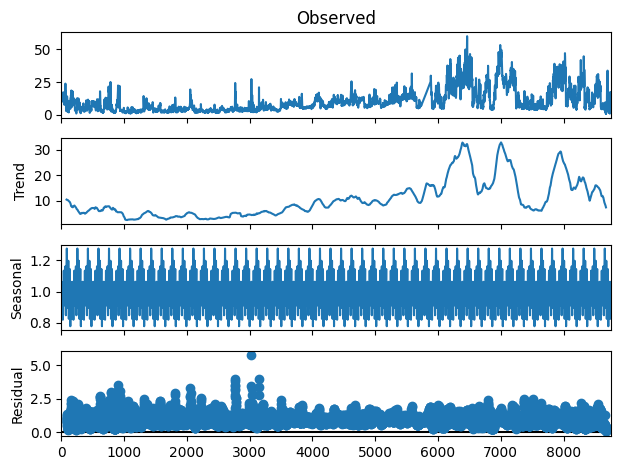

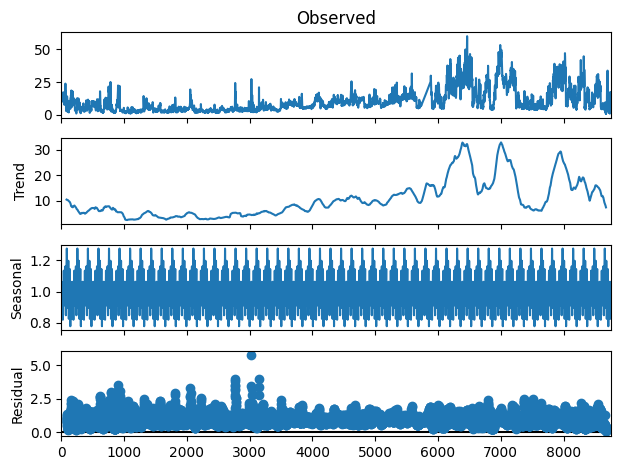

In [43]:
decompose_data = seasonal_decompose(data, model="multiplicative", period=24 * 7)
decompose_data.plot()

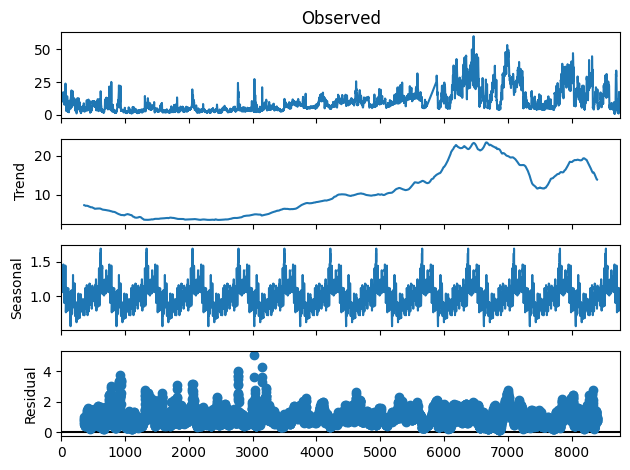

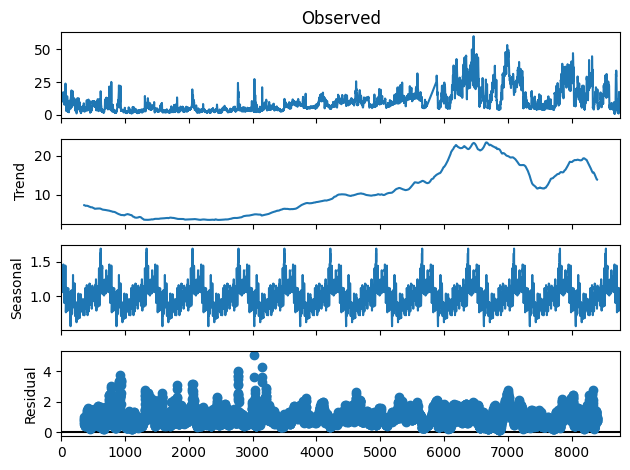

In [44]:
decompose_data = seasonal_decompose(data, model="multiplicative", period=24 * 30)
decompose_data.plot()

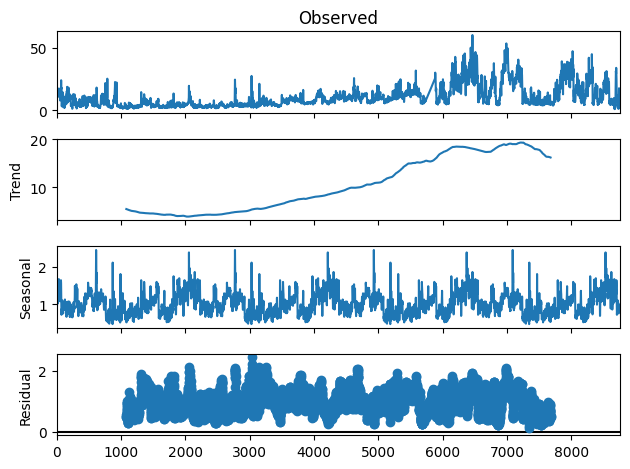

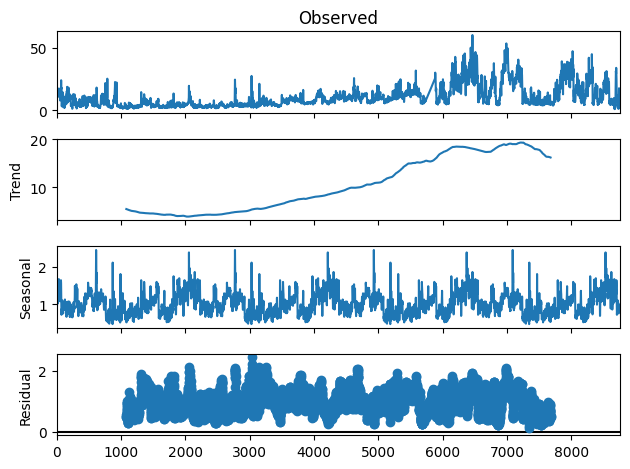

In [45]:
decompose_data = seasonal_decompose(data, model="multiplicative", period=24 * 30 * 3)
decompose_data.plot()

## By month estimation error

### Prepare Data

In [12]:
X_all_by_month = {i: [] for i in range(1, 13)}
Y_all_by_month = {i: [] for i in range(1, 13)}

dir_path = "./data/processed/purpleair/"

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    for month in range(1, 13):
        df_temp = df[df["month"] == month]
        X_all_by_month[month].append(df_temp[["longitude", "latitude"]].values)
        Y_all_by_month[month].append(df_temp["pm25"].values)

for month in range(1, 13):
    X_all_by_month[month] = np.array(X_all_by_month[month]).transpose(1, 0, 2)
    Y_all_by_month[month] = np.array(Y_all_by_month[month]).transpose(1, 0)

    print(f"Month {month}", end=" ")
    print(X_all_by_month[month].shape, end="  ")
    print(Y_all_by_month[month].shape)


Month 1 (744, 32, 2)  (744, 32)
Month 2 (672, 32, 2)  (672, 32)
Month 3 (744, 32, 2)  (744, 32)
Month 4 (720, 32, 2)  (720, 32)
Month 5 (744, 32, 2)  (744, 32)
Month 6 (720, 32, 2)  (720, 32)
Month 7 (744, 32, 2)  (744, 32)
Month 8 (744, 32, 2)  (744, 32)
Month 9 (720, 32, 2)  (720, 32)
Month 10 (744, 32, 2)  (744, 32)
Month 11 (720, 32, 2)  (720, 32)
Month 12 (744, 32, 2)  (744, 32)


/var/folders/h9/6347jhns5fv4jgpmcl4fl7dh0000gn/T/ipykernel_3782/3295375993.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="month_str", y="MAE", data=df_MAE.sort_values(by="month"),


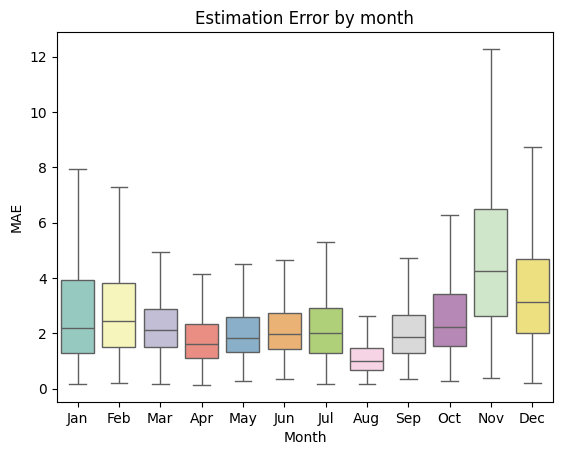

In [18]:
MAE_by_month = {i: [] for i in range(1, 13)}

for month in range(1, 13):
    X_month, Y_month = X_all_by_month[month], Y_all_by_month[month]
    for seed in range(0, 25):
        # train test split
        X_train, Y_train, X_test, Y_test = train_test_split(X_month, Y_month, seed=seed)

        # IDW
        for t in range(len(X_train)):
            idw = IDW(X_train[t], Y_train[t])
            pred = idw.predict(X_test[t])
            MAE_by_month[month].append(np.mean(np.abs(pred - Y_test[t])))

df_MAE = pd.DataFrame()
for month in range(1, 13):
    df_MAE = pd.concat([df_MAE, pd.DataFrame({"month": [month] * len(MAE_by_month[month]),
                                              "MAE": MAE_by_month[month],
                                              "month_str": [month_n2s(month)] * len(MAE_by_month[month])})])


sns.boxplot(x="month_str", y="MAE", data=df_MAE.sort_values(by="month"),
            palette="Set3", showfliers=False)
plt.xlabel("Month")
plt.title("Estimation Error by month")
plt.show()